In [1]:
!pip install ultralytics split-folders

from google.colab import drive
drive.mount('/content/drive')

print("Libraries installed and Drive mounted successfully!")

Mounted at /content/drive
Libraries installed and Drive mounted successfully!


In [2]:
import splitfolders

input_folder = '/content/drive/MyDrive/Bangladeshi_Vehicles_Raw'

output_folder = '/content/dataset'

print("Splitting dataset... This might take a minute depending on the number of images.")
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .2), group_prefix=None)

print("Dataset successfully split into 'train' and 'val' folders inside '/content/dataset'!")

Splitting dataset... This might take a minute depending on the number of images.


Copying files: 3384 files [02:56, 19.13 files/s] 

Dataset successfully split into 'train' and 'val' folders inside '/content/dataset'!


In [3]:
from ultralytics import YOLO

model = YOLO('yolov8n-cls.pt')

print("Starting training process...")

results = model.train(
    data='/content/dataset',
    epochs=20,
    imgsz=224,
    batch=16,
    project='bd_vehicles_project',
    name='yolov8_training_run'
)

print("Training complete! Model weights are saved.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Starting training process...
Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0

In [4]:
print("Evaluating model accuracy on validation set...")
metrics = model.val()

print(f"Top-1 Accuracy: {metrics.top1:.4f}")
print(f"Top-5 Accuracy: {metrics.top5:.4f}")

Evaluating model accuracy on validation set...
Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n-cls summary (fused): 30 layers, 1,442,566 parameters, 0 gradients, 3.3 GFLOPs
train: /content/dataset/train... found 2705 images in 6 classes ✅ 
val: /content/dataset/val... found 679 images in 6 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 896.9±479.1 MB/s, size: 144.4 KB)
val: Scanning /content/dataset/val... 679 images, 0 corrupt: 100% ━━━━━━━━━━━━ 679/679 18.1Mit/s 0.0s
val: /content/dataset/val/Cng/cng (389).jpg: corrupt JPEG restored and saved
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 43/43 1.3s/it 57.8s
                   all      0.984          1
Speed: 0.0ms preprocess, 14.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
Top-1 Accuracy: 0.9838
Top-5 Accuracy: 1.0000


Displaying Confusion Matrix:


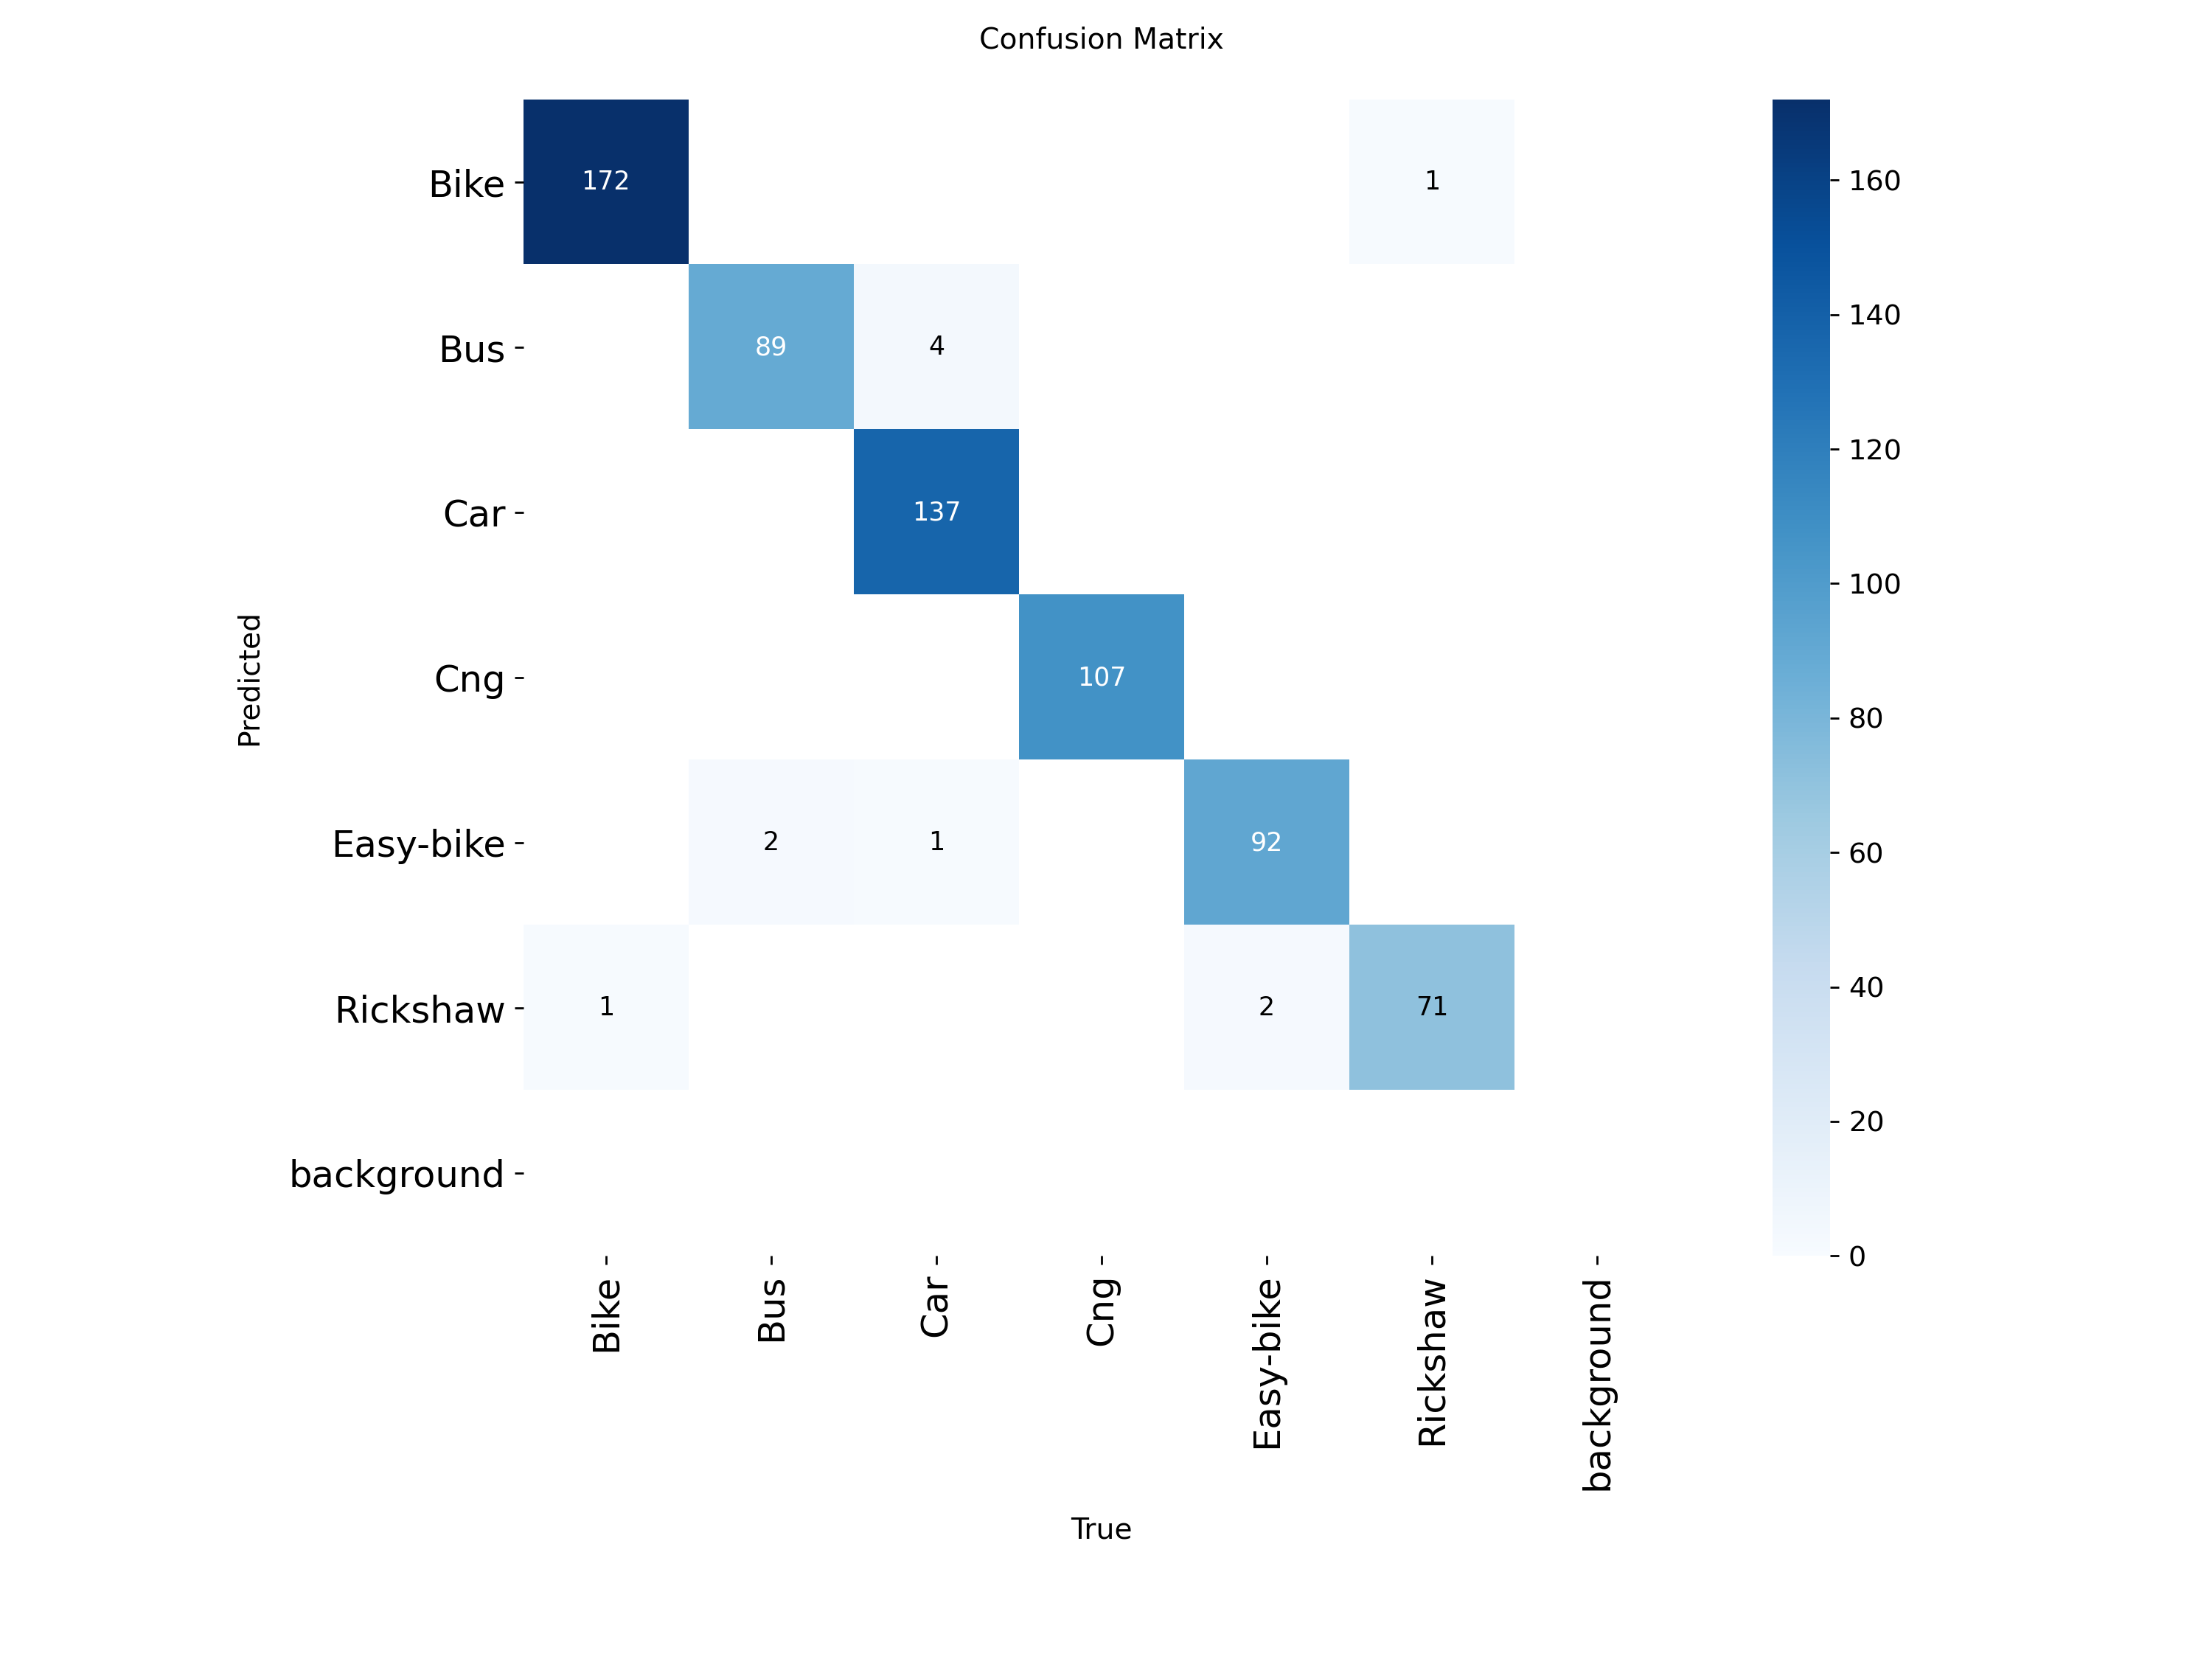

In [8]:
from IPython.display import Image, display
import os

confusion_matrix_path = '/content/runs/classify/bd_vehicles_project/yolov8_training_run/confusion_matrix.png'

if os.path.exists(confusion_matrix_path):
    print("Displaying Confusion Matrix:")
    display(Image(filename=confusion_matrix_path))
else:
    print("Confusion matrix not found. Let's list the files to see what is inside the folder:")
    !ls /content/runs/classify/bd_vehicles_project/yolov8_training_run/

In [11]:
test_image_path = '/content/drive/MyDrive/test_image.jpg'

if os.path.exists(test_image_path):
    prediction_results = model.predict(source=test_image_path)

    for result in prediction_results:
        top_class_id = result.probs.top1
        top_class_name = result.names[top_class_id]
        confidence = result.probs.top1conf.item() * 100

        print(f"\nPrediction: This is a {top_class_name.upper()} ({confidence:.2f}% confidence)")
else:
    print(f"Test image not found at {test_image_path}. Please upload one and update the path.")


image 1/1 /content/drive/MyDrive/test_image.jpg: 224x224 Cng 1.00, Bus 0.00, Easy-bike 0.00, Bike 0.00, Rickshaw 0.00, 17.2ms
Speed: 10.7ms preprocess, 17.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

Prediction: This is a CNG (100.00% confidence)


In [12]:
print("=== MODEL SPECIFICATIONS FOR YOUR RESOLUTION TABLE ===")
print(f"Model Architecture: YOLOv8n-cls (Nano Classification)")
print(f"Total Parameters: 1,442,566 (1.4M)")
print(f"Computational Complexity: 3.3 GFLOPs")
print(f"Image Resolution Used: 224 x 224 pixels\n")

print("=== INFERENCE SPEED PER IMAGE (VALIDATION SET) ===")

preprocess_speed = metrics.speed['preprocess']
inference_speed = metrics.speed['inference']
postprocess_speed = metrics.speed['postprocess']
total_speed = preprocess_speed + inference_speed + postprocess_speed

print(f"Preprocessing Speed: {preprocess_speed:.2f} ms")
print(f"Inference Speed (Neural Network): {inference_speed:.2f} ms")
print(f"Postprocessing Speed: {postprocess_speed:.2f} ms")
print(f"Total Latency per Image: {total_speed:.2f} ms")
print(f"Frames Per Second (FPS) Capability: {1000 / total_speed:.1f} FPS")

=== MODEL SPECIFICATIONS FOR YOUR RESOLUTION TABLE ===
Model Architecture: YOLOv8n-cls (Nano Classification)
Total Parameters: 1,442,566 (1.4M)
Computational Complexity: 3.3 GFLOPs
Image Resolution Used: 224 x 224 pixels

=== INFERENCE SPEED PER IMAGE (VALIDATION SET) ===
Preprocessing Speed: 0.00 ms
Inference Speed (Neural Network): 13.97 ms
Postprocessing Speed: 0.00 ms
Total Latency per Image: 13.97 ms
Frames Per Second (FPS) Capability: 71.6 FPS
